In [29]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

In [30]:
# Problem definition (this is not known by the decision maker)

# probabilities for sunny, windy, rainy
weather_distribution = {
    "sunny": 0.41,
    "windy": 0.26,
    "rainy": 0.33
}
weather_conditions = list(weather_distribution.keys())
weather_probs = np.array(list(weather_distribution.values()))
num_weathers = len(weather_distribution)

In [31]:

def sunny_utility(water):
    return 7 - (water - 3)**2

def windy_utility(water):
    return 4 - (water - 2)**2

def rainy_utility(water):
    return 2 - (water - 1)**2


# TO FILL
optimal_water = {
    "sunny": 3,
    "windy": 2,
    "rainy": 1
}

def get_optimal_action_for(weather):
    return optimal_water[weather]


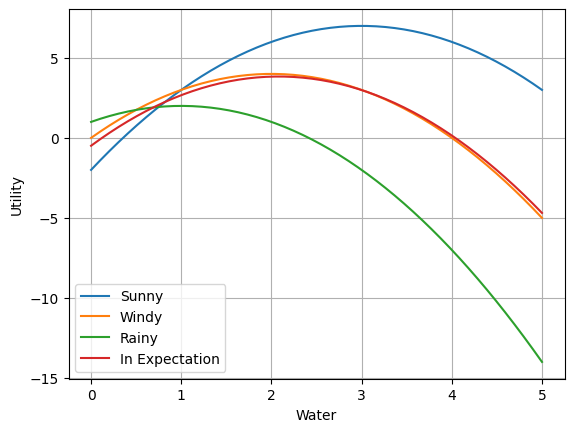

In [32]:
# a simple plot to visualise the actual utility function.
water = np.linspace(0, 5)

sunny_u = sunny_utility(water)
windy_u = windy_utility(water)
rainy_u = rainy_utility(water)

expected_utility = sunny_u * weather_distribution["sunny"] + windy_u * weather_distribution["windy"] + rainy_u * weather_distribution["rainy"] 

plt.grid()
plt.xlabel("Water")
plt.ylabel("Utility")
plt.plot(water, sunny_u, label="Sunny")
plt.plot(water, windy_u, label="Windy")
plt.plot(water, rainy_u, label="Rainy")
plt.plot(water, expected_utility, label="In Expectation")
plt.legend()

In [33]:
# TO FILL 
def compute_mse_gradient(observed: float, predicted: float) -> np.ndarray:
    # compute the gradient for the mse loss: (observed - predicted)^2
    # For the gradient we need to take the derivative of the loss function w.r.t. prediction:
    return 2*(predicted - observed)

# TO FILL 
def update_estimate(observed: float, estimate: np.ndarray, learning_rate: float) -> np.ndarray:
    # update our estimates by taking a gradient step
    return estimate - learning_rate * compute_mse_gradient(observed, estimate)
    

In [34]:
# We want to estimate the amount of water that yields the highest expected utility.
estimate = 0.  # Start with an arbitrary estimate for the best water amount.
num_samples = 10000
learning_rate_schedule = np.linspace(0.01, 0, num_samples)

for i, learning_rate in enumerate(learning_rate_schedule, 1):
    # Sample a random weather condition from the true distribution
    weather = np.random.choice(weather_conditions, p=weather_probs)
    
    # TO FILL
    optimal_action = get_optimal_action_for(weather)
    estimate = update_estimate(optimal_action, estimate, learning_rate)

    if i == 1 or i % 500 == 0:
        print("Sampled amount:", i)
        print("Estimates:", estimate)
        print("Estimated best action:", estimate)
    

Sampled amount: 1
Estimates: 0.04
Estimated best action: 0.04
Sampled amount: 500
Estimates: 2.11791028799699
Estimated best action: 2.11791028799699
Sampled amount: 1000
Estimates: 2.0414544521783773
Estimated best action: 2.0414544521783773
Sampled amount: 1500
Estimates: 2.0818210880799066
Estimated best action: 2.0818210880799066
Sampled amount: 2000
Estimates: 2.0521051673146182
Estimated best action: 2.0521051673146182
Sampled amount: 2500
Estimates: 2.0606319788471708
Estimated best action: 2.0606319788471708
Sampled amount: 3000
Estimates: 2.0845897616030316
Estimated best action: 2.0845897616030316
Sampled amount: 3500
Estimates: 2.103418501078862
Estimated best action: 2.103418501078862
Sampled amount: 4000
Estimates: 2.278351820903871
Estimated best action: 2.278351820903871
Sampled amount: 4500
Estimates: 2.052080870170754
Estimated best action: 2.052080870170754
Sampled amount: 5000
Estimates: 2.1430845900340265
Estimated best action: 2.1430845900340265
Sampled amount: 550